#### Importing Required Libararies:

In [159]:
import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate
import time

#### Loading data and preprocessor:

In [47]:
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

preprocessor = joblib.load("../outputs/models/preprocessor.pkl")

# Application and Evaluation of different ML models:

I did that because it will prevent the repition of code.

#### Perform Cross Validation:

This function perform cross-validation on the training data.

In [95]:
def perform_cross_validation(pipeline, X_train, y_train):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1,
        return_train_score=False
    )

    cv_results_df = pd.DataFrame(cv_results)

    cv_results_df = cv_results_df.drop(
        columns=["fit_time", "score_time"]
    )

    return cv_results_df

#### Print Fold-wise Results:

This fuction print fold-wise cross-validation results.

In [105]:
def print_cv_fold_results(cv_results):
    df = pd.DataFrame({
        "Fold": range(1, len(cv_results["test_accuracy"]) + 1),
        "Accuracy": cv_results["test_accuracy"],
        "Precision": cv_results["test_precision"],
        "Recall": cv_results["test_recall"],
        "F1 Score": cv_results["test_f1"],
        "ROC AUC": cv_results["test_roc_auc"]
    })

    return df

#### Print Average Cross Validation Results:

Print average cross-validation metrics.

In [112]:
def print_cv_average_results(cv_results):
    cv_df = pd.DataFrame(cv_results)

    print(f"Accuracy  : {cv_df['test_accuracy'].mean():.4f}")
    print(f"Precision : {cv_df['test_precision'].mean():.4f}")
    print(f"Recall    : {cv_df['test_recall'].mean():.4f}")
    print(f"F1 Score  : {cv_df['test_f1'].mean():.4f}")
    print(f"ROC AUC   : {cv_df['test_roc_auc'].mean():.4f}")

#### Print Standard Deviation:

Print the standard deviation of cross-validation metrics.

In [116]:
def print_cv_standard_deviation(cv_results):

    cv_df = pd.DataFrame(cv_results)


    print(f"Accuracy  : {cv_df['test_accuracy'].std():.4f}")
    print(f"Precision : {cv_df['test_precision'].std():.4f}")
    print(f"Recall    : {cv_df['test_recall'].std():.4f}")
    print(f"F1 Score  : {cv_df['test_f1'].std():.4f}")
    print(f"ROC AUC   : {cv_df['test_roc_auc'].std():.4f}")

#### Fit Pipeline:

This function train the pipeline and record training time.

In [60]:
def fit_pipeline(pipeline, X_train, y_train):
    start_time = time.perf_counter()
    pipeline.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time
    
    return pipeline, training_time

#### Predict:

This function generate predictions on both training and test sets.

In [61]:
def predict_pipeline(pipeline, X_train, X_test):

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):

        train_probabilities = pipeline.predict_proba(X_train)[:, 1]
        test_probabilities = pipeline.predict_proba(X_test)[:, 1]

    else:

        train_probabilities = None
        test_probabilities = None

    return (
        train_predictions,
        test_predictions,
        train_probabilities,
        test_probabilities
    )

#### Print Test Metrics:

In [122]:
def print_test_metrics(y_test, test_predictions, test_probabilities):

    accuracy = accuracy_score(y_test, test_predictions)
    precision = precision_score(y_test, test_predictions)
    recall = recall_score(y_test, test_predictions)
    f1 = f1_score(y_test, test_predictions)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    if test_probabilities is not None:
        roc_auc = roc_auc_score(y_test, test_probabilities)

        print(f"ROC AUC   : {roc_auc:.4f}")

        metrics["ROC AUC"] = roc_auc

    return metrics

#### Print Confusion Matrix:

This fuction plots confusion matrix.

In [64]:
def print_confusion_matrix(y_test, test_predictions, model_name):
    
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions)

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

#### Plot ROC Curve:

This function plot ROC curve if probabilities are available.

In [65]:
def plot_roc_curve(
    y_test,
    test_probabilities,
    model_name
):
    if test_probabilities is None:
        print(f"ROC curve is not available for {model_name}.")
        return

    RocCurveDisplay.from_predictions(
        y_test,
        test_probabilities
    )

    plt.title(f"{model_name} - ROC Curve")
    plt.show()

#### Compare Train vs Test Performance:

Compare training and test performance to check for overfitting.

In [127]:
def compare_train_vs_test(y_train, train_predictions, y_test, test_predictions):

    # Training metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    train_precision = precision_score(y_train, train_predictions)
    train_recall = recall_score(y_train, train_predictions)
    train_f1 = f1_score(y_train, train_predictions)

    # Test metrics
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_precision = precision_score(y_test, test_predictions)
    test_recall = recall_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions)

    comparison_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Training": [
            train_accuracy,
            train_precision,
            train_recall,
            train_f1
        ],
        "Test": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1
        ]
    })

    comparison_df["Difference"] = abs(
        comparison_df["Training"] - comparison_df["Test"]
    )

    comparison_df[["Training", "Test", "Difference"]] = comparison_df[
        ["Training", "Test", "Difference"]
    ].round(4)

    return comparison_df

### 1. Random Forest:

In [69]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

##### Perform Cross Validation:

In [88]:
cv_results = perform_cross_validation(
    pipeline=random_forest_pipeline,
    X_train=X_train,
    y_train=y_train
)

##### Print Fold-wise CV Results:

In [107]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,1.000000,0.982759,0.991304,0.999739
1,2,0.945055,0.948276,0.964912,0.956522,0.983488
2,3,0.934066,1.000000,0.894737,0.944444,0.985294
3,4,0.923077,0.962963,0.912281,0.936937,0.979876
4,5,0.989011,1.000000,0.982456,0.991150,0.999484


#####  Print Average CV Results:

In [114]:
print_cv_average_results(cv_results)

Accuracy  : 0.9560
Precision : 0.9822
Recall    : 0.9474
F1 Score  : 0.9641
ROC AUC   : 0.9896


##### Print Standard Deviation:

In [117]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0311
Precision : 0.0249
Recall    : 0.0412
F1 Score  : 0.0258
ROC AUC   : 0.0094


##### Train the Pipeline:

In [118]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=random_forest_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"\nTraining Time: {training_time:.4f} seconds")


Training Time: 0.7004 seconds


##### Make Predictions:

In [120]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

##### Print Test Metrics:

In [123]:
metrics = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9737
Precision : 0.9857
Recall    : 0.9718
F1 Score  : 0.9787
ROC AUC   : 0.9980


##### Print Confusion Matrix:

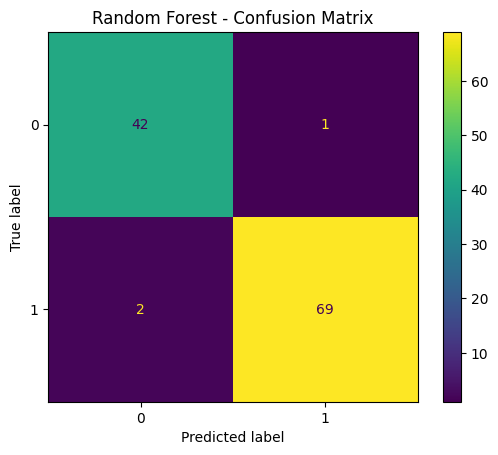

In [124]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Random Forest"
)

##### Plot ROC Curve:

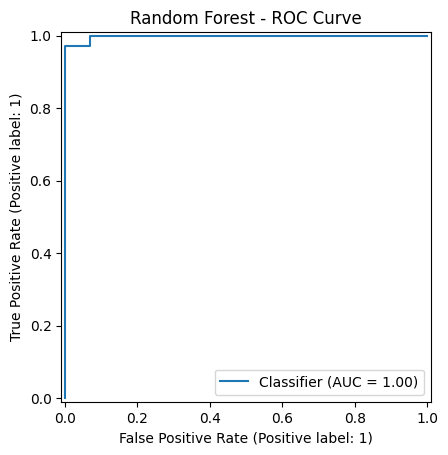

In [125]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Random Forest"
)

##### Compare Training and Test Performance:

In [128]:
compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

,Metric,Training,Test,Difference
0,Accuracy,1.0,0.9737,0.0263
1,Precision,1.0,0.9857,0.0143
2,Recall,1.0,0.9718,0.0282
3,F1 Score,1.0,0.9787,0.0213


### 2. Logistic Regression:

In [140]:
logistic_regression_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [141]:
cv_results = perform_cross_validation(
    pipeline=logistic_regression_pipeline ,
    X_train=X_train,
    y_train=y_train
)

In [142]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.956044,0.965517,0.965517,0.965517,0.995298
1,2,0.956044,0.964912,0.964912,0.964912,0.985036
2,3,0.978022,1.000000,0.964912,0.982143,0.999484
3,4,0.978022,0.982456,0.982456,0.982456,0.998452
4,5,0.978022,0.982456,0.982456,0.982456,0.997420


In [143]:
print_cv_average_results(cv_results)

Accuracy  : 0.9692
Precision : 0.9791
Recall    : 0.9721
F1 Score  : 0.9755
ROC AUC   : 0.9951


In [144]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0120
Precision : 0.0145
Recall    : 0.0095
F1 Score  : 0.0094
ROC AUC   : 0.0059


In [154]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=logistic_regression_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"\nTraining Time: {training_time:.4f} seconds")



Training Time: 0.0561 seconds


In [155]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [156]:
metrics = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)


Accuracy  : 0.9825
Precision : 0.9859
Recall    : 0.9859
F1 Score  : 0.9859
ROC AUC   : 0.9974


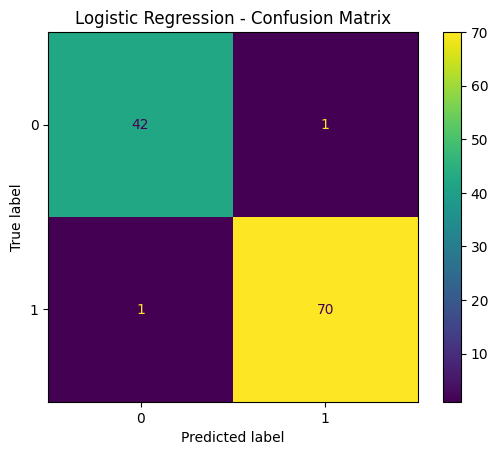

In [157]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Logistic Regression"
)

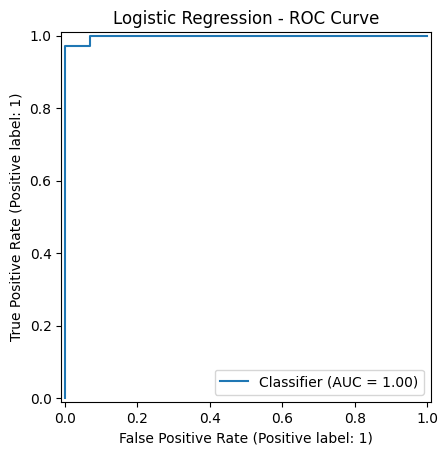

In [151]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Logistic Regression"
)

In [158]:
compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

,Metric,Training,Test,Difference
0,Accuracy,0.9890,0.9825,0.0066
1,Precision,0.9895,0.9859,0.0036
2,Recall,0.9930,0.9859,0.0071
3,F1 Score,0.9913,0.9859,0.0054


### 3. Decision Tree:

In [160]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

In [161]:
cv_results = perform_cross_validation(
    pipeline=decision_tree_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [162]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.967033,0.966102,0.982759,0.974359,0.961076
1,2,0.879121,0.883333,0.929825,0.905983,0.861971
2,3,0.890110,0.927273,0.894737,0.910714,0.888545
3,4,0.912088,0.962264,0.894737,0.927273,0.917957
4,5,0.912088,0.915254,0.947368,0.931034,0.900155


In [163]:
print_cv_average_results(cv_results)

Accuracy  : 0.9121
Precision : 0.9308
Recall    : 0.9299
F1 Score  : 0.9299
ROC AUC   : 0.9059


In [164]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0339
Precision : 0.0344
Recall    : 0.0373
F1 Score  : 0.0270
ROC AUC   : 0.0369


In [166]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=decision_tree_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0604 seconds


In [167]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [174]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9577
F1 Score  : 0.9784
ROC AUC   : 0.9789


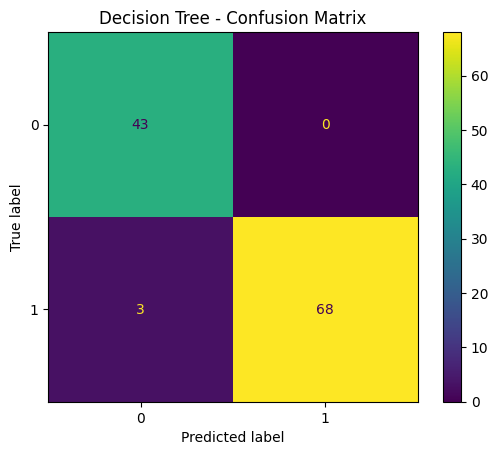

In [175]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Decision Tree"
)

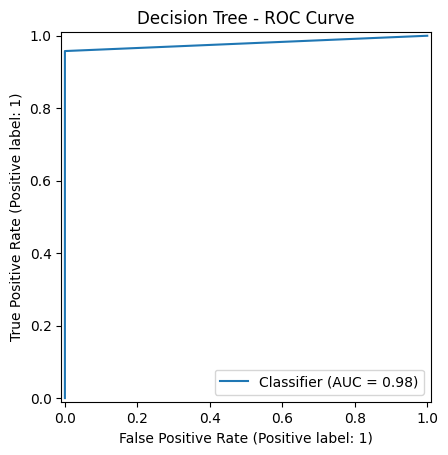

In [176]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Decision Tree"
)

In [177]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,1.0,0.9737,0.0263
1,Precision,1.0,1.0000,0.0000
2,Recall,1.0,0.9577,0.0423
3,F1 Score,1.0,0.9784,0.0216


### XgBoost:

In [178]:
xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [179]:
cv_results = perform_cross_validation(
    pipeline=xgboost_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [180]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,0.983051,1.000000,0.991453,0.998955
1,2,0.945055,0.933333,0.982456,0.957265,0.977296
2,3,0.912088,0.962264,0.894737,0.927273,0.989680
3,4,0.956044,0.981818,0.947368,0.964286,0.989680
4,5,0.978022,0.982456,0.982456,0.982456,0.998968


In [181]:
print_cv_average_results(cv_results)

Accuracy  : 0.9560
Precision : 0.9686
Recall    : 0.9614
F1 Score  : 0.9645
ROC AUC   : 0.9909


In [182]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0301
Precision : 0.0216
Recall    : 0.0419
F1 Score  : 0.0249
ROC AUC   : 0.0089


In [185]:
trained_pipeline, training_time = fit_pipeline(
    pipeline=xgboost_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.1496 seconds


In [186]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [188]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9649
Precision : 0.9718
Recall    : 0.9718
F1 Score  : 0.9718
ROC AUC   : 0.9957


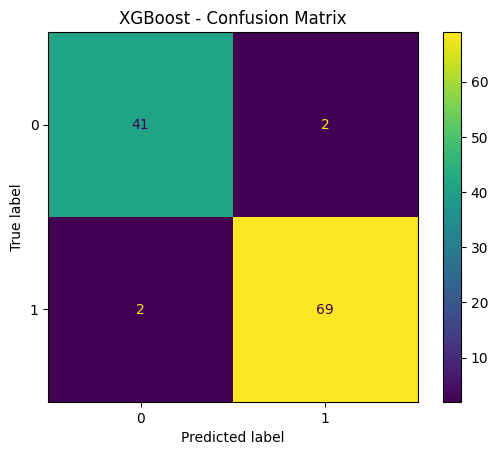

In [189]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="XGBoost"
)

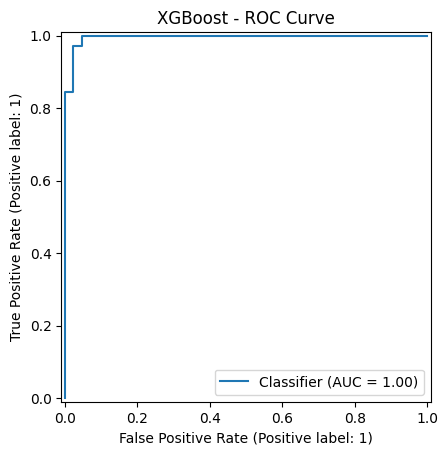

In [190]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="XGBoost"
)

In [191]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,1.0,0.9649,0.0351
1,Precision,1.0,0.9718,0.0282
2,Recall,1.0,0.9718,0.0282
3,F1 Score,1.0,0.9718,0.0282
